---
title: Estimating time-varying transmission rate from data
jupyter: python3
---

::: {.callout-warning}
Epymorph's Bayesian filtering functionality is currently in beta and subject to change. 
:::

### Scenario

A particle filter is an algorithm which can use data to estimate the states and parameters of an `epymorph` model. The particle filter accomplishes this by combining the data with a mathematical model.

This vignette will demonstrate how to use `epymorph`'s built-in particle filter to estimate both the time-varying transmission rate (beta) and state variables $S,I,R,H$ using weekly influenza hospitalization data. In the first exercise, we will define our model setup and generate synthetic data (fake data used for testing) which will be used to validate the particle filter. In the second exercise, we will setup the particle filter and run it on the synthetic data we generated in the first exercise. By validating the particle filter setup on synthetic data first, we can diagnose any issues before moving on to real data. In the third exercise, we will run the particle filter on real influenza hospitalization data. Because we will have already tested the particle filter on synthetic data, this step will be as easy as swapping out the synthetic data for the real data.


## Exercise 1

In this first exercise, we will setup our mathematical model and generate synthetic data.

In [1]:
from epymorph.adrio import acs5, csv
from epymorph.data.ipm.sirh import SIRH
from epymorph.data.mm.no import No
from epymorph.initializer import SingleLocation
import numpy as np
from epymorph.kit import *

- [ ] Generate a time series for beta, which will be used to generate the synthetic data. In this case, we'll assume a sinusoidal function to force beta.

In [2]:
num_weeks = 26
duration = 7 * num_weeks + 1
t = np.arange(0, duration)
true_beta = 0.1 * np.cos(t * 2 * np.pi / (365)) + 0.25

- [ ] Plot the values of this "true" or known transmission rate over time. 

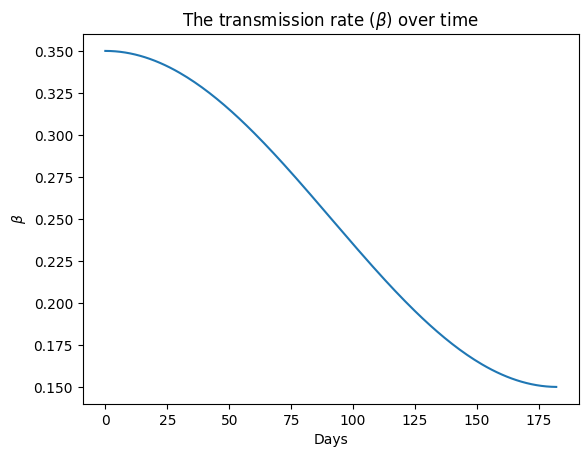

In [3]:
#| eval: false

import matplotlib.pyplot as plt

plt.plot(t, true_beta)
plt.ylabel("$\\beta$")
plt.xlabel("Days")
plt.title("The transmission rate ($\\beta$) over time")
plt.show()

![](img/G1-pf/beta_plot.png)

- [ ] Setup the model that will be used in the particle filter. It is important that the model has a hospitalized compartment since the real data is hospitalization data. In this case, we’ll use `epymorph`’s biult in SIRH model. Visualize the model diagram to confirm our understanding. We can see there is a fork between I and H/R. 

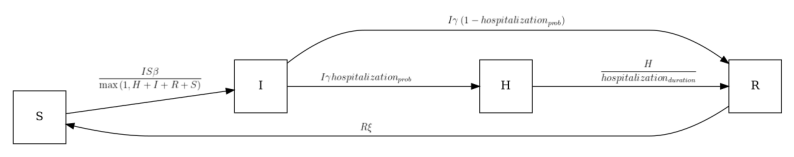

In [4]:
#| eval: false

my_ipm = SIRH()
my_ipm.diagram()

![](img/G1-pf/pf-SIRH-diagram.png)

- [ ] Generate a RUME using an Arizona State-level scope, and other requirements as specified below.

In [5]:
rume = SingleStrataRUME.build(
    ipm=SIRH(),
    mm=No(),
    scope=StateScope.in_states(["AZ"], year=2015),
    init=SingleLocation(0,100),
    time_frame=TimeFrame.of("2022-09-15", 7 * 26 + 1),
    params={
        "beta": true_beta,
        "gamma": 0.2,
        "xi": 1 / 365,
        "hospitalization_prob": 200 / 100_000,
        "hospitalization_duration": 5.0,
        "population": acs5.Population(),
    },
)

- [ ] Run the model.

In [6]:
rng = np.random.default_rng(seed=1)

sim = BasicSimulator(rume)
with sim_messaging(live = False):
    out = sim.run(rng_factory=(lambda: rng))

Loading gpm:all::init::population (epymorph.adrio.acs5.Population):
  |####################| 100%  (1.126s)
Running simulation (BasicSimulator):
• 2022-09-15 to 2023-03-16 (183 days)
• 1 geo nodes
  |####################| 100% 
Runtime: 0.027s


- [ ] Use epymorph’s aggregation functionality to aggregate the weekly hospital admissions, then save the synthetic data to numpy array. In this case we are specifying that the data observations are new hospitalizations, aggregated per seven days.

In [7]:
from epymorph.time import EveryNDays
from epymorph.tools.data import munge

from epymorph.util import to_date_value_array

quantity_selection = rume.ipm.select.events("I->H")
time_selection = rume.time_frame.select.all().group(EveryNDays(7)).agg()
geo_selection = rume.scope.select.all()

cases_df = munge(
    out,
    quantity=quantity_selection,
    time=time_selection,
    geo=geo_selection,
)

cases_arr = to_date_value_array(
    cases_df["time"].to_numpy(), cases_df["I → H"].to_numpy()
)[...,np.newaxis]

- [ ] Utilize `epymorph`'s builtin plotting functionality to examine the data. 

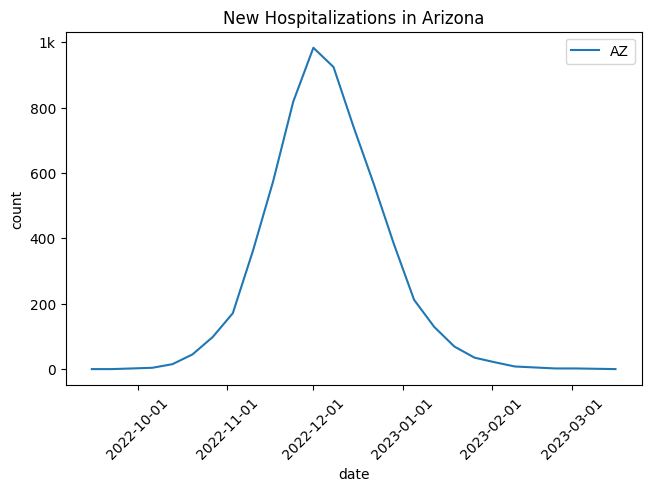

In [8]:
#| eval: false

out.plot.line(geo = geo_selection, 
time = time_selection,
quantity = quantity_selection, 
title = 'New Hospitalizations in Arizona',
label_format = "{n}")

![](img/G1-pf/epy_line_plot.png)

## Exercise 2

In this second exercise, we will run the particle filter on the synthetic data we generated and compare the estimate of beta produced by the particle filter to the true values of beta which were used to generate the data.

We now define the rume associated with the particle filter. This represents the model we plan to use for inference. Note that the only difference from the model used for generating the synthetic data is the specification of $\beta$. We choose to estimate $\ln \beta$ and perform an exponential transform to ensure $\beta$ remains positive (a negative $\beta$ is non-physical).

- [ ] Create the particle filtering rume, specifying $\ln \beta$ as a parameter to be estimated.  

In [9]:
from epymorph.forecasting.dynamic_params import ExponentialTransform

pf_rume = SingleStrataRUME.build(
    ipm=SIRH(),
    mm=No(),
    scope=StateScope.in_states(["AZ"], year=2015),
    init=SingleLocation(0,100),
    time_frame=TimeFrame.of("2022-09-15", 7 * 26 + 1),
    params={
        "beta": ExponentialTransform('log_beta'),
        "gamma": 0.2,
        "xi": 1 / 365,
        "hospitalization_prob": 200 / 100_000,
        "hospitalization_duration": 5.0,
        "population": acs5.Population(),
    },
)

- [ ] Create the model link, which defines how the model and data are linked, using the same selectors used to generate the data.

In [10]:
from epymorph.forecasting.pipeline import ModelLink

#Make sure the selectors reference the pf_rume not the rume for the synthetic data. 
quantity_selection = pf_rume.ipm.select.events("I->H")
time_selection = pf_rume.time_frame.select.all().group(EveryNDays(7)).agg()
geo_selection = pf_rume.scope.select.all()

model_link=ModelLink(
    quantity=quantity_selection,
    time=time_selection,
    geo=geo_selection,
)

- [ ] Create the observations object and use the Poisson likelihood as the likelihood function used to evaluate the model predictions.

In [11]:
from epymorph.forecasting.likelihood import PoissonLikelihood
from epymorph.forecasting.pipeline import Observations
from epymorph.adrio.adrio import Context

observations = Observations(
    source=cases_arr,
    model_link=model_link,
    likelihood=PoissonLikelihood(),
)

- [ ] Define the unknown parameters and their dynamics. The prior describes the probability distribution we draw from to initialize the parameter for each particle. The dynamics describe how the parameter evolves in time. 

In [12]:
from epymorph.forecasting.dynamic_params import GaussianPrior,BrownianMotion
from epymorph.forecasting.pipeline import UnknownParam

my_unknown_params = {
    "log_beta": UnknownParam(
        prior=GaussianPrior(
            mean=np.log(0.4),
            standard_deviation=0.2
        ),
        dynamics=BrownianMotion(
            volatility = 0.07
        ),
    )
}

- [ ] Define the particle filter object. num_realizations is the number of particles to use in the algorithm run. save_trajectories saves the state of each particle at each simulation tau tick, this is useful for inference but may be memory intensive for multi-node systems. 

In [13]:
from epymorph.forecasting.pipeline import PipelineConfig, ParticleFilterSimulator

num_realizations = 100

particle_filter_simulator = ParticleFilterSimulator(
    config=PipelineConfig.from_rume(
        pf_rume, num_realizations, unknown_params=my_unknown_params
    ),
    observations=observations,
)

- [ ] Execute the particle filter. 

In [14]:
particle_filter_output = particle_filter_simulator.run(rng=rng)

Observation: 0, Label: 2022-09-15, Time Frame: 2022-09-15/2022-09-21 (7D)
Observation: 1, Label: 2022-09-22, Time Frame: 2022-09-22/2022-09-28 (7D)
Observation: 2, Label: 2022-09-29, Time Frame: 2022-09-29/2022-10-05 (7D)
Observation: 3, Label: 2022-10-06, Time Frame: 2022-10-06/2022-10-12 (7D)
Observation: 4, Label: 2022-10-13, Time Frame: 2022-10-13/2022-10-19 (7D)
Observation: 5, Label: 2022-10-20, Time Frame: 2022-10-20/2022-10-26 (7D)
Observation: 6, Label: 2022-10-27, Time Frame: 2022-10-27/2022-11-02 (7D)
Observation: 7, Label: 2022-11-03, Time Frame: 2022-11-03/2022-11-09 (7D)
Observation: 8, Label: 2022-11-10, Time Frame: 2022-11-10/2022-11-16 (7D)
Observation: 9, Label: 2022-11-17, Time Frame: 2022-11-17/2022-11-23 (7D)
Observation: 10, Label: 2022-11-24, Time Frame: 2022-11-24/2022-11-30 (7D)
Observation: 11, Label: 2022-12-01, Time Frame: 2022-12-01/2022-12-07 (7D)
Observation: 12, Label: 2022-12-08, Time Frame: 2022-12-08/2022-12-14 (7D)
Observation: 13, Label: 2022-12-15,

The particle filter output emcompasses a number of useful metrics and data outputs from the run. Here, we are interested in the estimates of $\beta,S,I,R,H$ and associated 95% credible interval. We will also plot the fit to the data, this provides a useful sanity check to ensure the algorithm is working appropriately. 

- [ ] Plot the median and 95% credible intervals of $\beta,S,I,R$, and $H$. 

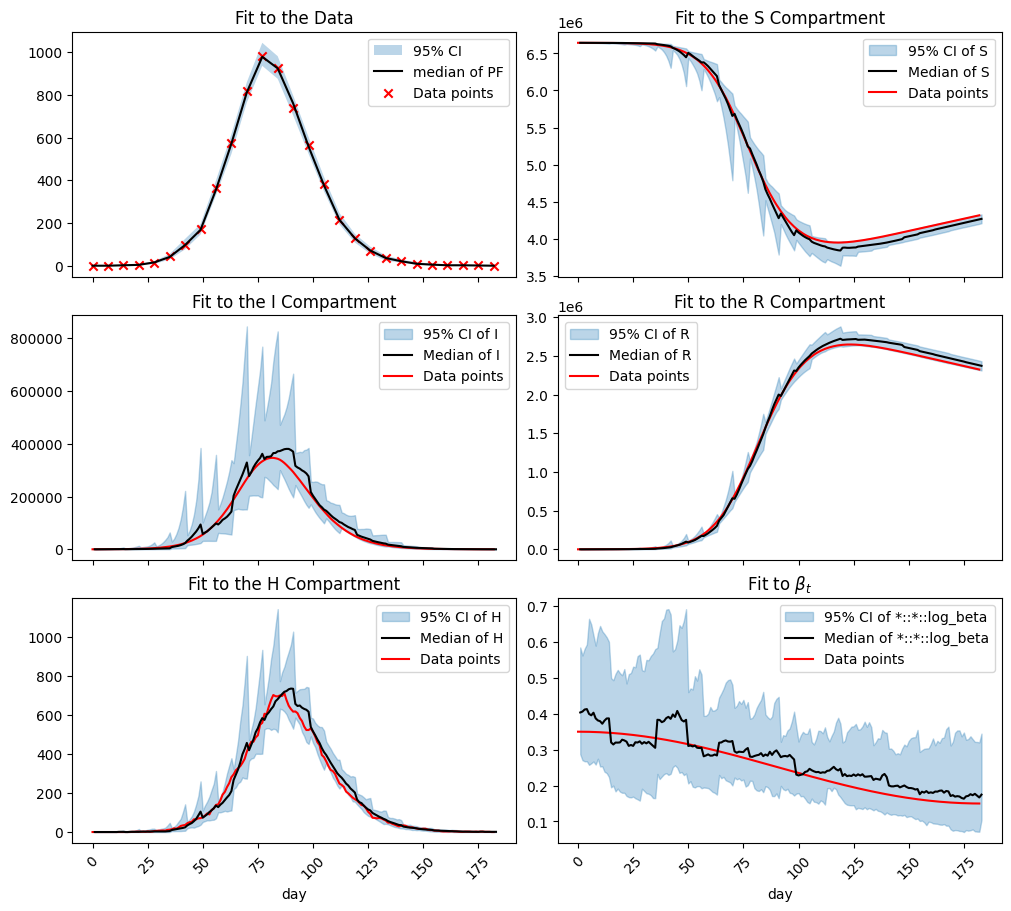

In [22]:
from epymorph.forecasting.filter_plot import PlotRendererPipeline
from math import exp

plotter = PlotRendererPipeline(particle_filter_output)

geo = rume.scope.select.all()
time = rume.time_frame.select.all()
data_date_range = np.arange(0, pf_rume.time_frame.days, 7)
sim_date_range = np.arange(0, pf_rume.time_frame.days, 1)

labels = ["S", "I", "R", "H"]
nrows = 3
ncols = 2

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(ncols * 5, nrows * 3),
    sharex=True,
    layout="constrained",
)

axes = axes.flatten()

axes[0].set_title("Fit to the Data")
axes[0].fill_between(
    data_date_range,
    np.percentile(particle_filter_output.posterior_values, 2.5, axis=0).squeeze(),
    np.percentile(particle_filter_output.posterior_values, 97.5, axis=0).squeeze(),
    label="95% CI",
    alpha=0.3,
)
axes[0].plot(
    data_date_range,
    np.median(particle_filter_output.posterior_values, axis=0).squeeze(),
    color="black",
    label="median of PF",
)
axes[0].scatter(
    data_date_range, cases_df["I → H"], marker="x", color="red", label="Data points"
)
axes[0].legend()

ax_index = 1
for label in labels:
    ax = axes[ax_index]
    quantity = rume.ipm.select.compartments(label)
    plotter.quantiles_plt(
        np.array([ax]),
        geo,
        time,
        quantity,
        line_kwargs=[{"color": "black"}],
        fill_kwargs=[{"color": "tab:blue", "alpha": 0.3}],
        credible_intervals=[95],
    )
    axes[ax_index].plot(
        sim_date_range, out.dataframe[label], color="red", label="Data points"
    )
    axes[ax_index].set_title(f'Fit to the {label} Compartment')

    axes[ax_index].legend()
    ax_index += 1

def exp_transform(data_df):
    exp_value = data_df["value"].apply(lambda x: exp(x))
    return data_df.assign(value=exp_value)

quantity = particle_filter_output.param_select.by_name('log_beta')
plotter.quantiles_plt(
        np.array([axes[-1]]),
        geo,
        time,
        quantity,
        line_kwargs=[{"color": "black"}],
        fill_kwargs=[{"color": "tab:blue", "alpha": 0.3}],
        credible_intervals=[95],
        transform = exp_transform
    )

axes[-1].set_title('Fit to $\\beta_t$')
axes[-1].plot(sim_date_range, true_beta, color="red", label="Data points")
axes[-1].legend()

plt.show()

![](img/G1-pf/pf-output.png)

## Notes

We see a strong fit to the data and that the algorithm has captured the downwards trajectory of $\beta$. While the median of the state variables hews closely to their true values we also observe a sawtooth effect in the 95% credible intervals. This is due to the sparsity of the data, weekly conditioning leads to sharp adjustments to the posterior distribution. 